# B. PRETRAINED MODERN CNN & FINE – TUNING MODEL (TORCH BASED)

In [5]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from dataset import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [7]:
data_dir = "./dataset"
train_loader, val_loader, class_names = get_dataloaders(
    root_dir=data_dir,
    val_size=500,
    batch_size=32,
    image_size=224,
    num_workers=2
)

print("Classes:", class_names)
print("Number of train set:", len(train_loader.dataset))
print("Number of validation set:", len(val_loader.dataset))

images, labels = next(iter(train_loader))
print("Batch train size:", images.shape)
print("Batch label size:", labels.shape)

Classes: ['cats', 'dogs', 'panda']
Number of train set: 2500
Number of validation set: 500
Batch train size: torch.Size([32, 3, 224, 224])
Batch label size: torch.Size([32])


In [8]:
criterion = nn.CrossEntropyLoss()

def train_model(model, optimizer, epochs=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "time_per_epoch": []
    }
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        epoch_time = time.time() - start_time
        tr_loss = train_loss / train_total
        tr_acc = (train_correct / train_total) * 100.0
        vl_loss = val_loss / val_total
        vl_acc = (val_correct / val_total) * 100.0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["time_per_epoch"].append(epoch_time)

        print(f"Epoch {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.2f}%")

    return history

### Case 1: Đóng băng toàn bộ Backbone

Thực hiện đóng băng toàn bộ Backbone, chỉ mở khóa huấn luyện lớp phân loại FC.

In [9]:
from resnet50 import ResNet50

model_frozen = ResNet50(num_classes=len(class_names), pretrained=True, freeze_backbone=True).to(device)
optimizer_frozen = optim.AdamW(filter(lambda p: p.requires_grad, model_frozen.parameters()), lr=1e-3)

print("Case 1: Freeze ALL backbone")
history_frozen = train_model(model_frozen, optimizer_frozen, epochs=5)

Case 1: Freeze ALL backbone
Epoch 1/5 | Time: 6.74s | Train Loss: 0.4233 Acc: 90.16% | Val Loss: 0.1514 Acc: 97.60%
Epoch 2/5 | Time: 6.47s | Train Loss: 0.1873 Acc: 94.20% | Val Loss: 0.0950 Acc: 99.00%
Epoch 3/5 | Time: 6.45s | Train Loss: 0.1537 Acc: 95.32% | Val Loss: 0.0656 Acc: 99.00%
Epoch 4/5 | Time: 6.44s | Train Loss: 0.1365 Acc: 94.72% | Val Loss: 0.0540 Acc: 99.00%
Epoch 5/5 | Time: 6.41s | Train Loss: 0.1211 Acc: 95.60% | Val Loss: 0.0406 Acc: 99.20%


### Case 2: Mở một phần Backbone

Ở đây mở Block Layer 4, blokc trích xuất đặc trưng cuối cùng. l1, l2, l3 vẫn được đóng băng, với chỉ số learning rate = 1e-4, 1e-3 cho fc.

In [10]:
model_partial = ResNet50(num_classes=len(class_names), pretrained=True)
model_partial.unfreeze_last_blocks(1)
param_groups = model_partial.get_param_groups(lr_backbone=1e-4, lr_classifier=1e-3)
optimizer_partial = optim.AdamW(param_groups)

print("Case 2: Partial Fine-tuning (layer4 + fc)")
history_partial = train_model(model_partial.to(device), optimizer_partial, epochs=5)

Case 2: Partial Fine-tuning (layer4 + fc)
Epoch 1/5 | Time: 6.57s | Train Loss: 0.2718 Acc: 89.60% | Val Loss: 0.0279 Acc: 98.40%
Epoch 2/5 | Time: 6.57s | Train Loss: 0.1263 Acc: 95.12% | Val Loss: 0.0236 Acc: 99.00%
Epoch 3/5 | Time: 6.62s | Train Loss: 0.0960 Acc: 96.36% | Val Loss: 0.0169 Acc: 99.60%
Epoch 4/5 | Time: 6.54s | Train Loss: 0.0816 Acc: 96.92% | Val Loss: 0.0144 Acc: 99.60%
Epoch 5/5 | Time: 6.51s | Train Loss: 0.0852 Acc: 96.80% | Val Loss: 0.0197 Acc: 99.20%


### Case 3: Mở toàn bộ

In [11]:
model_full = ResNet50(num_classes=len(class_names), pretrained=True)
model_full.unfreeze_all()
param_groups = model_full.get_param_groups(lr_backbone=1e-5, lr_classifier=1e-3)
optimizer_full = optim.AdamW(param_groups)

print("Case 3: Full Fine-tuning (all layers)")
history_full = train_model(model_full.to(device), optimizer_full, epochs=5)

Case 3: Full Fine-tuning (all layers)
Epoch 1/5 | Time: 12.75s | Train Loss: 0.3665 Acc: 89.84% | Val Loss: 0.0863 Acc: 99.00%
Epoch 2/5 | Time: 12.74s | Train Loss: 0.1323 Acc: 95.48% | Val Loss: 0.0423 Acc: 99.40%
Epoch 3/5 | Time: 12.74s | Train Loss: 0.1008 Acc: 96.44% | Val Loss: 0.0323 Acc: 99.40%
Epoch 4/5 | Time: 12.79s | Train Loss: 0.0856 Acc: 97.04% | Val Loss: 0.0228 Acc: 99.60%
Epoch 5/5 | Time: 12.84s | Train Loss: 0.0761 Acc: 97.28% | Val Loss: 0.0189 Acc: 99.60%


In [12]:
summary_data = {
    "Strategy": ["Freeze All (Case 1)", "Partial (Case 2)", "Full Fine-tuning (Case 3)"],
    "Train Acc (%)": [
        round(history_frozen["train_acc"][-1], 2),
        round(history_partial["train_acc"][-1], 2),
        round(history_full["train_acc"][-1], 2)
    ],
    "Val Acc (%)": [
        round(max(history_frozen["val_acc"]), 2),
        round(max(history_partial["val_acc"]), 2),
        round(max(history_full["val_acc"]), 2)
    ],
    "Avg Time/Epoch (s)": [
        round(np.mean(history_frozen["time_per_epoch"]), 2),
        round(np.mean(history_partial["time_per_epoch"]), 2),
        round(np.mean(history_full["time_per_epoch"]), 2)
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

                 Strategy  Train Acc (%)  Val Acc (%)  Avg Time/Epoch (s)
      Freeze All (Case 1)          95.60         99.2                6.50
         Partial (Case 2)          96.80         99.6                6.56
Full Fine-tuning (Case 3)          97.28         99.6               12.77


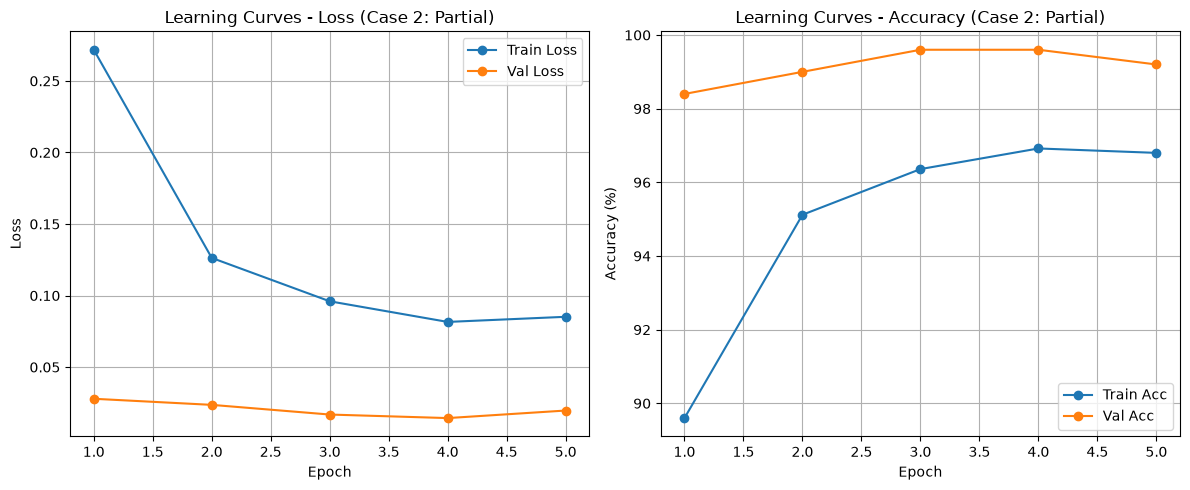

In [13]:
epochs_range = range(1, len(history_partial["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_partial["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs_range, history_partial["val_loss"], label="Val Loss", marker="o")
plt.title("Learning Curves - Loss (Case 2: Partial)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_partial["train_acc"], label="Train Acc", marker="o")
plt.plot(epochs_range, history_partial["val_acc"], label="Val Acc", marker="o")
plt.title("Learning Curves - Accuracy (Case 2: Partial)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Nhận xét

Về thời gian huấn luyện, kịch bản 1 (đóng băng toàn bộ) và kịch bản 2 (mở layer4) có tốc độ nhanh tương đương nhau, lần lượt đạt 6.50 giây và 6.56 giây mỗi epoch do giữ cố định phần lớn backbone. Ngược lại, kịch bản 3 (mở toàn bộ mạng) tốn tới 12.77 giây mỗi epoch, tức là tăng gần gấp đôi thời gian do phải cập nhật toàn bộ 50 tầng.

Về độ chính xác và khả năng hội tụ, kịch bản 1 đạt kết quả tốt với validation accuracy 99.20% nhờ tận dụng các đặc trưng sẵn có từ ImageNet. Kịch bản 2 mang lại hiệu quả vượt trội nhất khi tinh chỉnh các đặc trưng ngữ nghĩa cấp cao ở layer4, nâng accuracy lên 99.60% ngay từ epoch thứ 3 và ép validation loss xuống mức thấp kỷ lục là 0.0144. Kịch bản 3 dù đạt train accuracy cao nhất (97.28%) và validation accuracy 99.60% nhưng validation loss (0.0189) lại không sâu bằng kịch bản 2, cho thấy việc mở các tầng nông với lượng dữ liệu vừa phải là không cần thiết.

Đồ thị học tập của kịch bản 2 thể hiện sự ổn định cao khi loss giảm nhanh, accuracy hội tụ sớm và không có hiện tượng quá khớp. Tổng kết lại, kịch bản 2 (Partial Fine-tuning) chính là điểm cân bằng tối ưu nhất (sweet spot), mang lại độ chính xác cao nhất, hàm mất mát thấp nhất và tiết kiệm được một nửa thời gian so với việc mở toàn bộ mô hình.



Classification Report:
              precision    recall  f1-score   support

        cats       0.99      0.99      0.99       165
        dogs       0.99      0.99      0.99       154
       panda       0.99      1.00      1.00       181

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



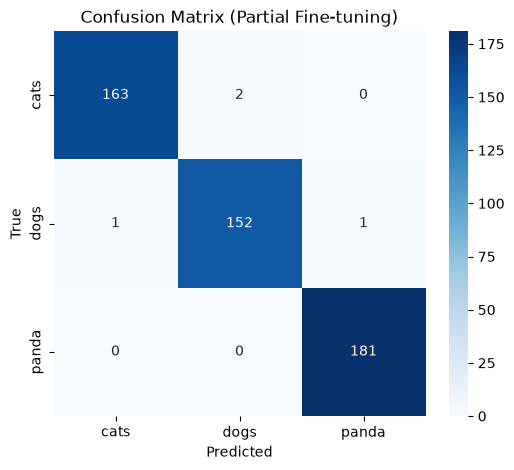

In [14]:
all_preds = []
all_labels = []

model_partial.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_partial(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Partial Fine-tuning)")
plt.show()


### Nhận xét

Mô hình thể hiện độ chính xác phân loại gần như tuyệt đối với accuracy đạt 99% trên toàn bộ 500 ảnh validation. Các điểm dữ liệu tập trung áp đảo dọc theo đường chéo chính của ma trận, cho thấy tỷ lệ đoán đúng rất đồng đều giữa các lớp.

Gấu trúc (panda)Đạt hiệu năng hoàn hảo với Recall 1.00 và F1-score 1.00 (dự đoán đúng toàn bộ 181/181 mẫu, không có mẫu nào bị nhầm sang lớp khác) nhờ đặc điểm màu lông đen trắng và hình thể rất đặc trưng.

Chó (dogs) và Mèo (cats) Cả hai lớp đều đạt Precision, Recall và F1-score ở mức 0.99. Sự nhầm lẫn là cực kỳ hiếm (chỉ khoảng 1 đến 2 mẫu bị nhầm lẫn lẫn nhau giữa chó và mèo ở một số góc chụp khuất hoặc đặc điểm lông tương đồng).